## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Data

In [ ]:
# Load Dataset
df_train = pd.read_csv('Train.csv')
df_test = pd.read_csv('Test.csv')
sample_data = pd.read_csv('sample_submission.csv')

# Copy
df_train = df_train.copy()
df_test = df_test.copy()
sample_data = sample_data.copy()

sample_data.head()

,ID,Segmentation
0,458989,A
1,458994,A
2,458996,A
3,459000,A
4,459001,A


## 3. Data Overview

### Train Dataset

In [ ]:
df_train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
# Basic info
print('Shape of df_train:', df_train.shape)
print('\nInfo of df_train:')
print(df_train.info())

Shape of df_train: (8068, 11)

Info of df_train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB
None


In [ ]:
# Summary statistics
print('Summary statistics of Numerical features:')
print(df_train.describe())

print('\nSummary statistics of Categorical features:')
display(df_train.describe(include='object').T)

Summary statistics of Numerical features:
                  ID          Age  Work_Experience  Family_Size
count    8068.000000  8068.000000      7239.000000  7733.000000
mean   463479.214551    43.466906         2.641663     2.850123
std      2595.381232    16.711696         3.406763     1.531413
min    458982.000000    18.000000         0.000000     1.000000
25%    461240.750000    30.000000         0.000000     2.000000
50%    463472.500000    40.000000         1.000000     3.000000
75%    465744.250000    53.000000         4.000000     4.000000
max    467974.000000    89.000000        14.000000     9.000000

Summary statistics of Categorical features:


,count,unique,top,freq
Gender,8068,2,Male,4417
Ever_Married,7928,2,Yes,4643
Graduated,7990,2,Yes,4968
Profession,7944,9,Artist,2516
Spending_Score,8068,3,Low,4878
Var_1,7992,7,Cat_6,5238
Segmentation,8068,4,D,2268


In [ ]:
# Check for missing values
print('Missing values in df_train:')
print(df_train.isnull().sum())

# Check for duplicates
print('\nNumber of duplicate rows in df_train:', df_train.duplicated().sum())

# Target distribution
print('\nTarget variable distribution:')
print(df_train['Segmentation'].value_counts())

Missing values in df_train:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

Number of duplicate rows in df_train: 0

Target variable distribution:
Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64


In [ ]:
# Percentage of Missing Values
missing_values = pd.DataFrame({
    'Missing Values %': (df_train.isnull().sum() / len(df_train)) * 100
    }).sort_values(by='Missing Values %', ascending=False)

missing_values[missing_values['Missing Values %'] > 0]

,Missing Values %
Work_Experience,10.275161
Family_Size,4.152206
Ever_Married,1.735250
Profession,1.536936
Graduated,0.966782
Var_1,0.941993


### Test Dataset

In [ ]:
df_test.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [ ]:
# Info of df_test
print('Shape of df_test:', df_test.shape)
print('\nInfo of df_test:')
print(df_test.info())

Shape of df_test: (2627, 10)

Info of df_test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB
None


In [ ]:
# Summary statistics of df_test
df_test.describe()

,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2358.000000,2514.000000
mean,463433.918919,43.649791,2.552587,2.825378
std,2618.245698,16.967015,3.341094,1.551906
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,4.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [ ]:
# Check for missing values
print('Missing values in df_test:')
print(df_test.isnull().sum())

# Check for duplicates
print('\nNumber of duplicate rows in df_test:', df_test.duplicated().sum())

Missing values in df_test:
ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64

Number of duplicate rows in df_test: 0


## 4. Cleaning Data

In [ ]:
# Define categorical and numerical features
num_cols = ['Age', 'Work_Experience', 'Family_Size']
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
target_col = ['Segmentation']

# Train
df_train_copy = df_train.copy()
df_train_copy[num_cols] = df_train_copy[num_cols].fillna(df_train_copy[num_cols].median())

cat_mode = df_train_copy[cat_cols].mode().iloc[0]
df_train_copy[cat_cols] = df_train_copy[cat_cols].fillna(cat_mode)

# Test
df_test_copy = df_test.copy()
df_test_copy[num_cols] = df_test_copy[num_cols].fillna(df_train_copy[num_cols].median())
df_test_copy[cat_cols] = df_test_copy[cat_cols].fillna(cat_mode)

In [ ]:
#check missing values after imputation
print('Missing values in df_train after imputation:')
print(df_train_copy.isnull().sum())

print('\nMissing values in df_test after imputation:')
print(df_test_copy.isnull().sum())


Missing values in df_train after imputation:
ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

Missing values in df_test after imputation:
ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64


In [ ]:
df_train_copy.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,A


In [ ]:
df_test_copy.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,Artist,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,1.0,Low,4.0,Cat_6


## 5. EDA

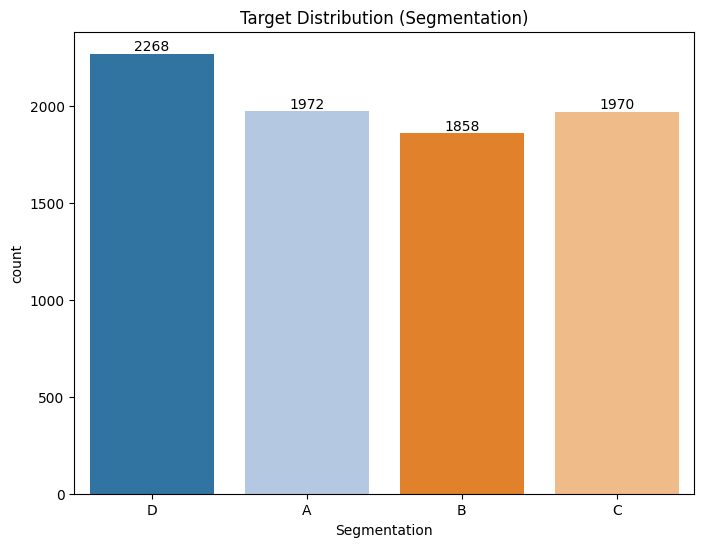

In [ ]:
#Distribution of target
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df_train_copy,
    hue='Segmentation',
    x='Segmentation',
    palette='tab20',
    legend=False
)

# labeling the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Target Distribution (Segmentation)')
plt.show()

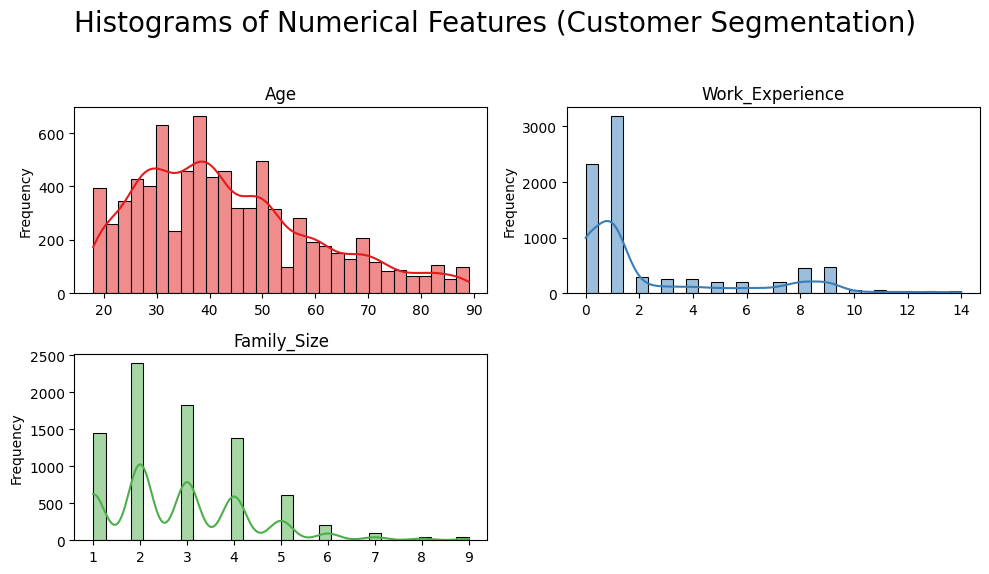

In [ ]:
# Histogram of numerical features
cust_num = df_train_copy[num_cols]

# Plot histograms
fig = plt.figure(figsize=(10, 6))

plt.suptitle(
    'Histograms of Numerical Features (Customer Segmentation)',
    horizontalalignment='center',
    fontstyle='normal',
    fontsize=20,
    fontfamily='sans-serif'
)

#Loop throughh numerical columns
for i, col in enumerate(cust_num.columns):
    plt.subplot(2, 2, i + 1)

    sns.histplot(
        data=cust_num,
        x=col,
        kde=True,
        bins=30,
        color=sns.color_palette('Set1')[i % 10]
    )

    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


The dataset shows that most customers are young to middle-aged individuals with low work experience and moderate family size, indicating a dominant segment of early-career professionals. Skewed distributions and potential outliers were identified, requiring scaling and transformation to improve clustering performance.

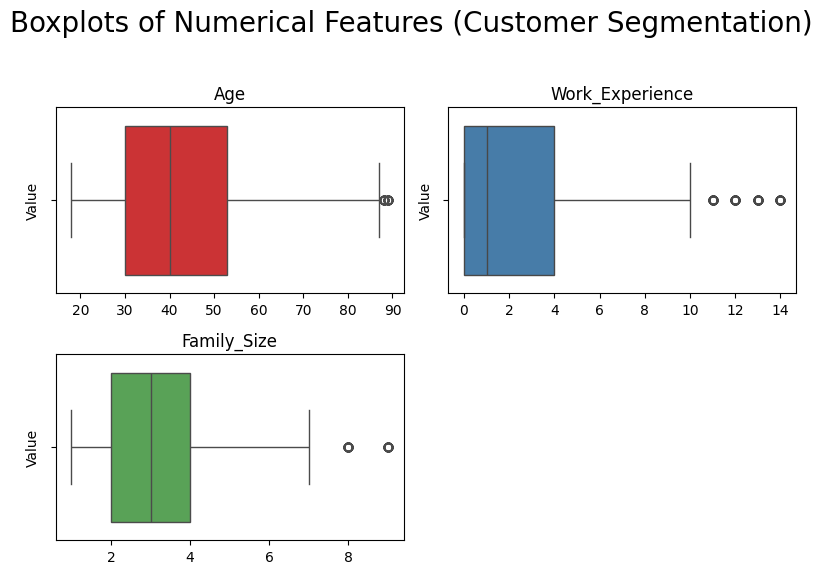

In [ ]:
# Boxplot for numerical features
fig = plt.figure(figsize=(8, 6))
plt.suptitle(
    'Boxplots of Numerical Features (Customer Segmentation)',
    horizontalalignment='center',
    fontstyle='normal',
    fontsize=20,
    fontfamily='sans-serif'
)
# Loop through numerical columns
for i, col in enumerate(cust_num.columns):
    plt.subplot(2, 2, i + 1)

    sns.boxplot(
        data=cust_num,
        x=col,
        color=sns.color_palette('Set1')[i % 10]
    )

    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Value')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Boxplot analysis reveals that Age is relatively well-distributed with minor outliers, while Work_Experience is highly skewed with significant outliers, potentially impacting clustering performance. Family_Size shows a stable distribution with a few large-family outliers. Appropriate transformation and scaling are required to ensure robust clustering.

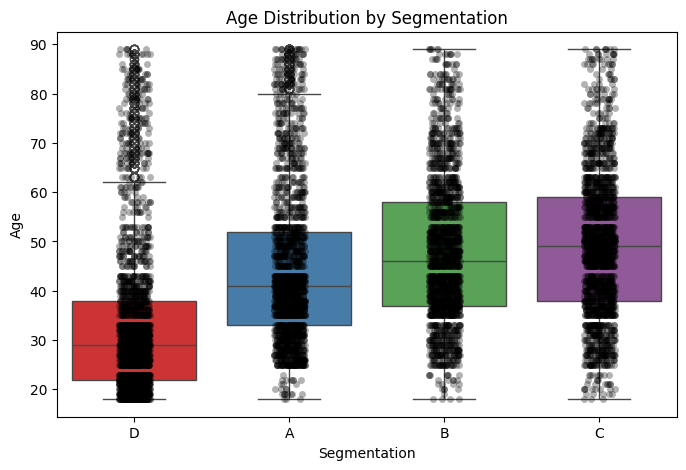

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_train_copy,
    x='Segmentation',
    y='Age',
    hue='Segmentation',
    palette='Set1',
    legend=False
)

sns.stripplot(
    data=df_train_copy,
    x='Segmentation',
    y='Age',
    color='black',
    alpha=0.3
)

plt.title('Age Distribution by Segmentation')
plt.xlabel('Segmentation')
plt.ylabel('Age')

plt.show()

Age distribution shows a clear progression across customer segments, with Segment D representing younger customers and Segment C representing older, more mature individuals. This indicates that age is a key feature in defining customer segments, although some overlap suggests additional features also contribute to clustering.

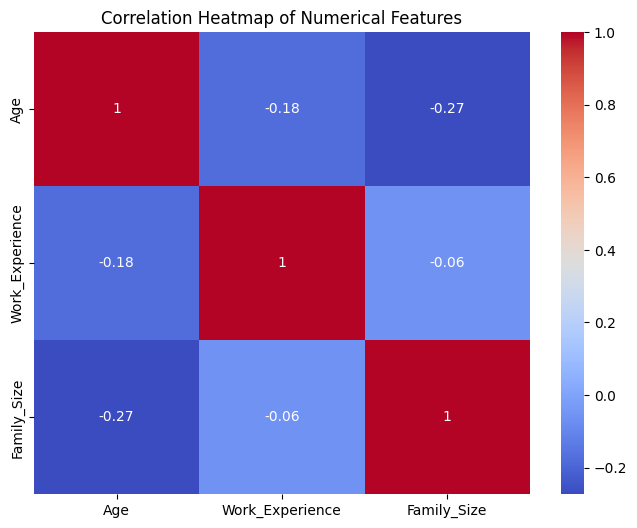

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(
    cust_num.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Correlation analysis shows weak relationships between features, indicating low multicollinearity. This suggests that each feature contributes independently to the clustering process, making the dataset suitable for segmentation tasks.

## 6. Feature Selection

## Chi-Square

In [ ]:
# Chi-Square Test for Categorical vs Target
from scipy.stats import chi2_contingency

def chi_square_test(col):
    contigency = pd.crosstab(df_train_copy[col], df_train_copy['Segmentation'])
    chi2, p, dof, ex = chi2_contingency(contigency)
    print(f"{col} -> p-value: {p}")

#test for each categorical feature
for col in cat_cols:
    chi_square_test(col)

Gender -> p-value: 0.009618143763412593
Ever_Married -> p-value: 1.8822655112027064e-296
Graduated -> p-value: 1.462416036568809e-229
Profession -> p-value: 0.0
Spending_Score -> p-value: 0.0
Var_1 -> p-value: 2.474310927613894e-41


All categorical features show a statistically significant relationship with customer segmentation, with Spending Score and Profession having the strongest influence

## Anova

In [ ]:
# Function of Anova
from scipy.stats import f_oneway

def anova_test(col):
    groups = []
    for seg in df_train_copy['Segmentation'].unique():
        groups.append(df_train_copy[df_train_copy['Segmentation'] == seg][col])

    f_stat, p = f_oneway(*groups)
    print(f"{col} -> p-value: {p}")

#test for each numerical feature
for col in num_cols:
    anova_test(col)

Age -> p-value: 2.188783270249291e-285
Work_Experience -> p-value: 2.6265210568344342e-12
Family_Size -> p-value: 4.942926515263521e-65


Numerical features (Age, Work Experience, and Family Size) show statistically significant differences across segments, indicating that these variables are important in distinguishing customer groups.

## 7.Encoding 

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Copy Data
df_train = df_train_copy.copy()
df_test = df_test_copy.copy()

# FREQUENCY ENCODING
# Profession
prof_freq = df_train['Profession'].value_counts()

df_train['Profession_freq'] = np.log1p(df_train['Profession'].map(prof_freq))
df_test['Profession_freq'] = np.log1p(df_test['Profession'].map(prof_freq).fillna(0))

# Var_1
var_freq = df_train['Var_1'].value_counts()

df_train['Var_1_freq'] = np.log1p(df_train['Var_1'].map(var_freq))
df_test['Var_1_freq'] = np.log1p(df_test['Var_1'].map(var_freq).fillna(0))

# DROP ORIGINAL CATEGORICAL
df_train = df_train.drop(columns=['Profession', 'Var_1'])
df_test = df_test.drop(columns=['Profession', 'Var_1'])


In [ ]:
df_train.head()

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Segmentation,Profession_freq,Var_1_freq
0,462809,Male,No,22,No,1.0,Low,4.0,D,7.195187,6.993933
1,462643,Female,Yes,38,Yes,1.0,Average,3.0,A,6.551080,6.993933
2,466315,Female,Yes,67,Yes,1.0,Low,1.0,B,6.551080,8.578288
3,461735,Male,Yes,67,Yes,0.0,High,2.0,B,6.436150,8.578288
4,462669,Female,Yes,40,Yes,1.0,High,6.0,A,6.856462,8.578288


In [ ]:
# Binary Mapping
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

for col in ['Gender', 'Ever_Married', 'Graduated']:
    df_train[col] = df_train[col].map(binary_map)
    df_test[col] = df_test[col].map(binary_map)

# Fearure Selection
numeric_features = ['Age', 'Work_Experience', 'Family_Size', 'Profession_freq', 'Var_1_freq']
binary_features = ['Gender', 'Ever_Married', 'Graduated']
categorical_features = ['Spending_Score']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

In [ ]:
# Aligning train and test features
X_train = df_train.drop(['ID', 'Segmentation'], axis=1)
X_test = df_test.drop(['ID'], axis=1)

# Fit and Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Check
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (8068, 11)
Test shape: (2627, 11)


In [ ]:
X_train.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Profession_freq,Var_1_freq
0,1,0,22,0,1.0,Low,4.0,7.195187,6.993933
1,0,1,38,1,1.0,Average,3.0,6.551080,6.993933
2,0,1,67,1,1.0,Low,1.0,6.551080,8.578288
3,1,1,67,1,0.0,High,2.0,6.436150,8.578288
4,0,1,40,1,1.0,High,6.0,6.856462,8.578288


## 9. Modelling KMeans

### Elbow Method

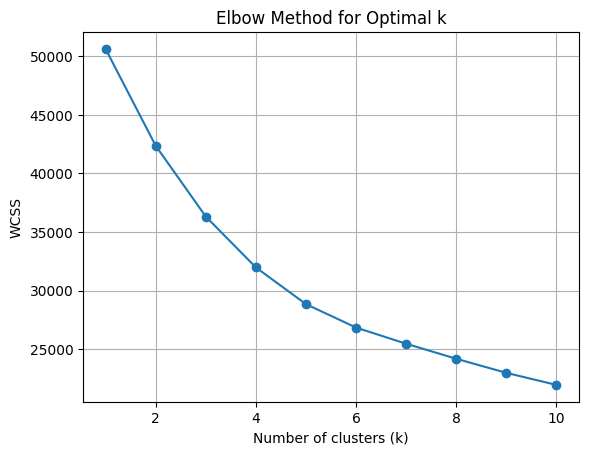

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_processed)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid()
plt.show()

### Silhouette Scorer

In [ ]:
from sklearn.metrics import silhouette_score

wcss = []
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_processed)
    
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train_processed, labels))
    
    print(f"k={k}, silhouette={sil_scores[-1]:.4f}")

k=2, silhouette=0.1618
k=3, silhouette=0.1862
k=4, silhouette=0.1855
k=5, silhouette=0.1825
k=6, silhouette=0.1842
k=7, silhouette=0.1872
k=8, silhouette=0.1849
k=9, silhouette=0.1906
k=10, silhouette=0.1800


In [ ]:
# Mostly based on silhouette score, we can choose k=4 as the optimal number of clusters
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Assign cluster labels to train and test data
df_train_copy['Cluster'] = kmeans.fit_predict(X_train_processed)
df_test_copy['Cluster'] = kmeans.predict(X_test_processed)

# Evaluation
print('\nCross-tabulation of Cluster vs Segmentation:')
pd.crosstab(df_train_copy['Cluster'], df_train['Segmentation'])



Cross-tabulation of Cluster vs Segmentation:


Segmentation,A,B,C,D
Cluster,,,,
0,513,372,335,1250
1,596,581,437,338
2,438,609,924,182
3,425,296,274,498


In [ ]:
pd.crosstab(df_train_copy['Cluster'], df_train_copy['Spending_Score'])

Spending_Score,Average,High,Low
Cluster,,,
0,320,154,1996
1,401,694,857
2,933,215,1005
3,320,153,1020


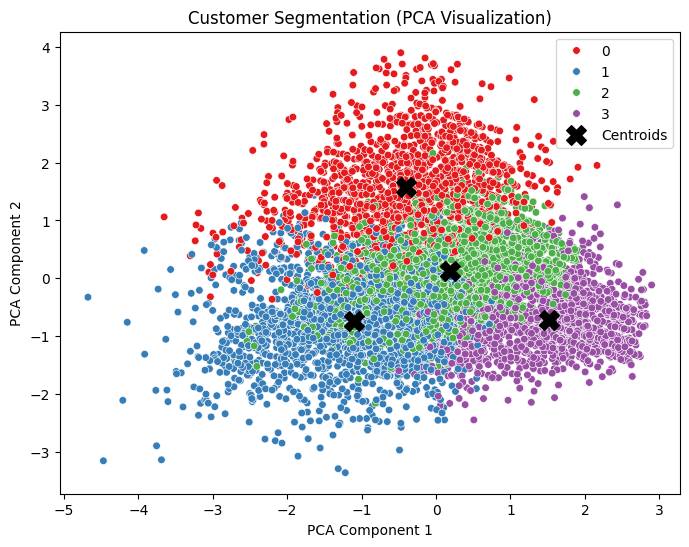

In [ ]:
from sklearn.decomposition import PCA

# Reduce ke 2 dimensi untuk visualisasi
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_train_processed)

# Train KMeans (pakai yang sudah benar)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_train_processed)

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_vis[:, 0],
    y=X_vis[:, 1],
    hue=clusters,
    palette='Set1',
    s=30
)

# Centroids
centroids_vis = pca_vis.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_vis[:, 0],
    centroids_vis[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation (PCA Visualization)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

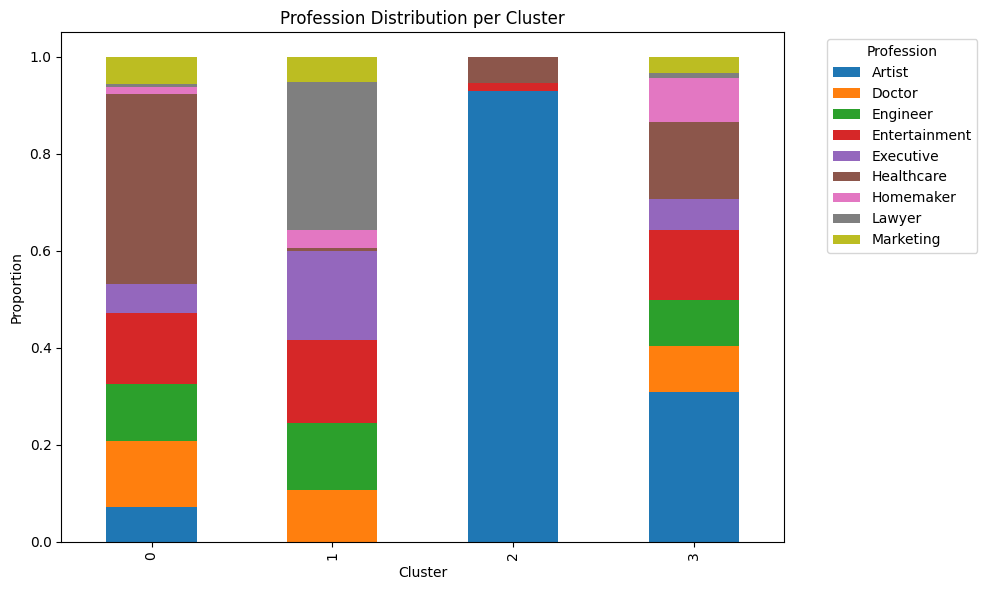

In [ ]:
prof_dist = pd.crosstab(
    df_train_copy['Cluster'],
    df_train_copy['Profession'],
    normalize='index'
)

prof_dist.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Profession Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title='Profession', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

🔍 Insights per Cluster
- Cluster 0 — Highly Dominant Profession 1
   - Almost entirely Artists (~90%+)
   - Very little variation in other professions

👉 Significance:
This cluster is very specific → likely unique segment characteristics (e.g., lifestyle, preferences, or spending patterns).

- Cluster 1 — Mixed but skewed toward several professions
   - Dominant: Lawyers, Executives, Entertainment, Engineers
   - Fairly even distribution compared to other clusters

👉 Significance:
This segment is heterogeneous but professional/high-skill oriented → likely an upper-middle segment with behavioral variations.

- Cluster 2 — Strong in Healthcare
   - Most dominant: Healthcare (~40%)
   - Followed by Doctors, Engineers, Entertainment

👉 Significance:
This cluster has a fairly clear identity → health-related professions
→ likely to have similar needs or preference patterns (e.g., stable income, utilitarian spending).

- Cluster 3 — Most Diverse
   - Combination: Artist, Engineer, Entertainment, Health, Housekeeper
   - No single profession is particularly dominant
   
👉 Significance:
This cluster is the most general/broad segment
→ likely a “mass market” or customers with a mix of characteristics.

🚀 Business Insight
- Cluster 0 (Artist-heavy) → can target creative/lifestyle campaigns
- Cluster 2 (Healthcare-heavy) → can focus on practical needs/stability
- Cluster 3 (General) → suitable for broad marketing strategies
- Cluster 1 (Professional mix) → can be targeted at premium/segmented offerings

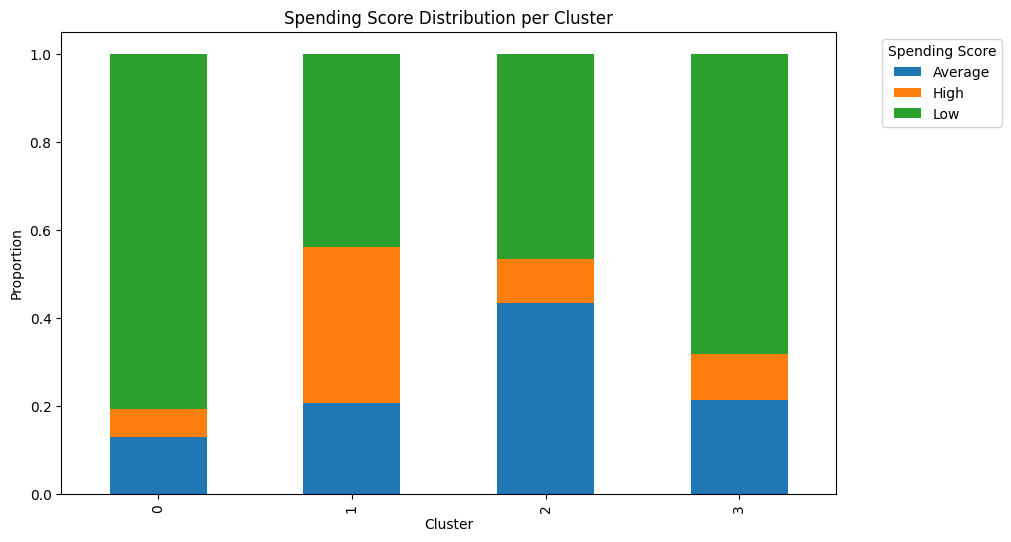

In [ ]:
import seaborn as sns

spending_dist = pd.crosstab(
    df_train_copy['Cluster'], 
    df_train_copy['Spending_Score'],
    normalize='index'
)

spending_dist.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Spending Score Distribution per Cluster')
plt.ylabel('Proportion')
plt.xlabel('Cluster')
plt.legend(title='Spending Score', bbox_to_anchor=(1.05,1))
plt.show()

In [ ]:
df_analysis = df_train_copy.copy()
df_analysis['Cluster'] = df_train_copy['Cluster']

# Numeric
num_summary = df_analysis.groupby('Cluster').mean(numeric_only=True)

# Categorical (contoh Spending)
cat_summary = df_analysis.groupby('Cluster')['Spending_Score'].value_counts(normalize=True)

print(num_summary)
print(cat_summary)

                    ID        Age  Work_Experience  Family_Size
Cluster                                                        
0        463542.071660  30.476518         1.139676     3.914575
1        463496.322746  60.248975         0.977971     2.263832
2        463422.697631  47.827218         1.191825     2.397585
3        463434.357669  36.728734         8.480911     2.541862
Cluster  Spending_Score
0        Low               0.808097
         Average           0.129555
         High              0.062348
1        Low               0.439037
         High              0.355533
         Average           0.205430
2        Low               0.466791
         Average           0.433349
         High              0.099861
3        Low               0.683188
         Average           0.214334
         High              0.102478
Name: proportion, dtype: float64


## 🔍 Insights per Cluster

Cluster 0 — Balanced (Average + Low)
   - Dominant: Average & low spending
   - High spending is very small

👉 Significance:

  This segment is quite stable but not aggressive in spending → casual customers (moderate value).

Cluster 1 — High Spender Segment
   - High spenders are the largest (~35%)
   - Low spenders are still present, but smaller than other clusters

👉 Significance:

This is the cluster with the most revenue potential → primary target for:
  - Best-selling
  - Loyalty programs
  - Premium offers

Cluster 2 — Low Spender Dominance
  - Low spenders are very dominant (~80%)
  - Almost no high spenders

👉 Significance:

This segment is price/value sensitive → suitable for:
  - Discount promotions
  - Campaign awareness
  - Not a high revenue priority

Cluster 3 — Mostly Low with Average
  - Low spenders remain dominant (~70%)
  - Some Average & High spenders are present

👉 Significance:

This segment is mass market but still has room for upgrading → opportunity for:
  - conversion to average/high spenders

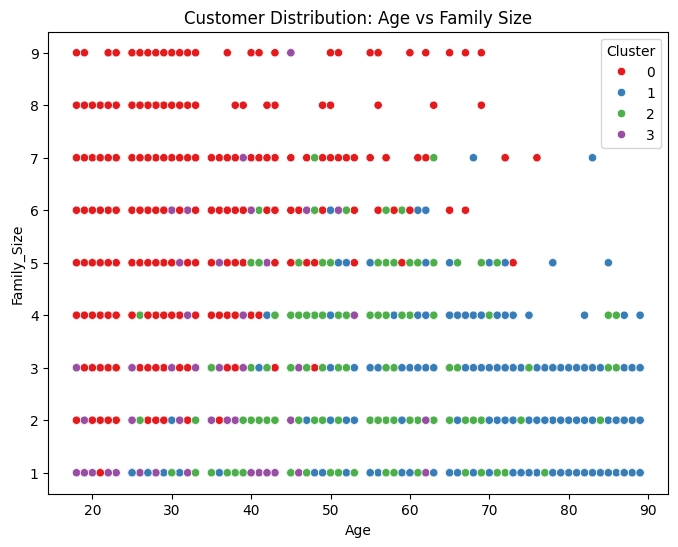

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_train_copy,
    x='Age',
    y='Family_Size',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Distribution: Age vs Family Size')
plt.show()

### Business Insight

🎯 Clear segmentation based on lifecycle

👶 Cluster 2 → “Young Individuals”

- Not yet have many dependents
- Early Career

👉 strategy:
- Entry-level Promotions
- Basic/trial Products

👨‍👩‍👧 Cluster 0 → “Family Builders”

- Large Families
- Productive Age

👉 strategy:
- Bundling
- Family Packages
- Volume Discounts

👴 Cluster 1 → “Mature/Empty Nest”

- High Age
- Small Families

👉 strategy:
- Premium Service
- Convenience Products
- Loyalty Programs

In [ ]:
# Save Joblib
import joblib

# Save in dictionary
model_package = {
    "preprocessor": preprocessor,
    "kmeans": kmeans,
    "prof_freq": prof_freq,
    "var_freq": var_freq
}

joblib.dump(model_package, "customer_segmentation_model.joblib")

print("Model saved successfully!")


Model saved successfully!
